# Assignment 2 — Multilayer Perceptron (MLP) for Wine Quality Classification

### Objective
Design and implement a **Multilayer Perceptron (MLP)** for classification of a wine dataset and evaluate its performance using **accuracy** and a **confusion matrix**.

**Dataset:** Wine Quality (WineQT.csv)  
**Framework:** TensorFlow / Keras  
**Environment:** Google Colab / Python 3


## 1. Import Required Libraries

TensorFlow/Keras is used to build and train the MLP. Pandas and NumPy are used for data handling, while scikit-learn provides preprocessing, train-test splitting, and evaluation utilities.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the Wine Dataset

The supplied WineQT.csv dataset contains physicochemical measurements of wine samples. The quality column is used as the classification target, while Id is an identifier and is excluded from the model features.

In [4]:
df = pd.read_csv("WineQT.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nMissing values:", df.isnull().sum().sum())
print("\nQuality distribution:")
print(df["quality"].value_counts().sort_index())

Dataset shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



Missing values: 0

Quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


## 3. Data Preparation

The target variable is `quality`. The identifier column `Id` is removed because it does not represent a wine characteristic. The remaining numerical attributes are used as input features.

In [5]:
X = df.drop(columns=["quality", "Id"])
y = df["quality"]

print("Feature matrix shape:", X.shape)
print("Target classes:", sorted(y.unique()))

Feature matrix shape: (1143, 11)
Target classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


## 4. Train-Test Split

The data is divided into **80% training** and **20% testing** subsets. Stratification is used so that the class distribution is preserved as much as possible in both subsets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 914
Testing samples: 229


## 5. Feature Standardization

The input features have different numerical ranges. Standardization transforms each feature using the training-set mean and standard deviation. The scaler is fitted **only on the training data** to avoid data leakage.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (914, 11)
Scaled testing shape: (229, 11)


## 6. Encode Target Classes

The wine-quality labels are 3, 4, 5, 6, 7, and 8. They are mapped to consecutive class indices so that they can be used with Keras' sparse categorical cross-entropy loss.

In [8]:
classes = np.sort(y.unique())
class_to_index = {label: index for index, label in enumerate(classes)}

y_train_encoded = y_train.map(class_to_index).to_numpy()
y_test_encoded = y_test.map(class_to_index).to_numpy()

print("Classes:", classes)
print("Encoded classes:", np.unique(y_train_encoded))

Classes: [3 4 5 6 7 8]
Encoded classes: [0 1 2 3 4 5]


## 7. Build the Multilayer Perceptron

The MLP contains an input layer, two hidden dense layers with ReLU activation, dropout for regularization, and a softmax output layer for multiclass classification.

In [9]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(len(classes), activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046 (11.90 KB)

 Trainable params: 3,046 (11.90 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the MLP

The model is trained on the standardized training features. A validation split is used to monitor performance during training.

In [10]:
history = model.fit(
    X_train_scaled,
    y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.3666 - loss: 1.6548 - val_accuracy: 0.4426 - val_loss: 1.4376
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4651 - loss: 1.3470 - val_accuracy: 0.4754 - val_loss: 1.2433
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5253 - loss: 1.1783 - val_accuracy: 0.5301 - val_loss: 1.1374
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5650 - loss: 1.0921 - val_accuracy: 0.5410 - val_loss: 1.0817
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5677 - loss: 1.0334 - val_accuracy: 0.5355 - val_loss: 1.0544
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5759 - loss: 1.0124 - val_accuracy: 0.5519 - val_loss: 1.0375
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5732 - loss: 0.9986 - val_accuracy: 0.5574 - val_loss: 1.0240
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5691 - loss: 0.9863 - val_accuracy: 0.5628 - val_loss

## 9. Evaluate Accuracy

Predictions are generated for the unseen test set and compared with the actual labels. Accuracy measures the proportion of correctly classified samples.

In [11]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 0.9535
Test accuracy: 64.19%


## 10. Confusion Matrix

A confusion matrix shows how the model's predictions are distributed across the actual wine-quality classes. It helps identify which quality levels are classified correctly or confused with one another.

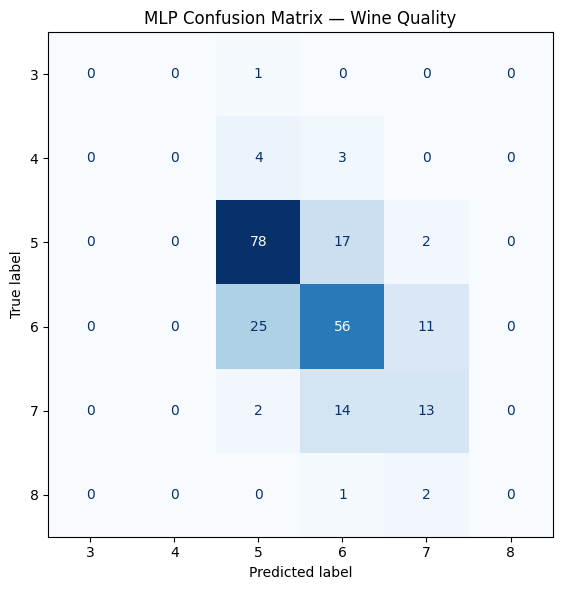

In [12]:
probabilities = model.predict(X_test_scaled, verbose=0)
predicted_indices = np.argmax(probabilities, axis=1)
predicted_labels = classes[predicted_indices]

cm = confusion_matrix(y_test, predicted_labels, labels=classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("MLP Confusion Matrix — Wine Quality")
plt.tight_layout()
plt.show()

## 11. Classification Report

Precision, recall, and F1-score provide class-wise evaluation in addition to overall accuracy.

In [13]:
print(classification_report(
    y_test,
    predicted_labels,
    labels=classes,
    target_names=[str(c) for c in classes],
    zero_division=0
))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.71      0.80      0.75        97
           6       0.62      0.61      0.61        92
           7       0.46      0.45      0.46        29
           8       0.00      0.00      0.00         3

    accuracy                           0.64       229
   macro avg       0.30      0.31      0.30       229
weighted avg       0.61      0.64      0.62       229



## 12. Visualize Training Performance

The training and validation curves show how accuracy and loss change over the training epochs.

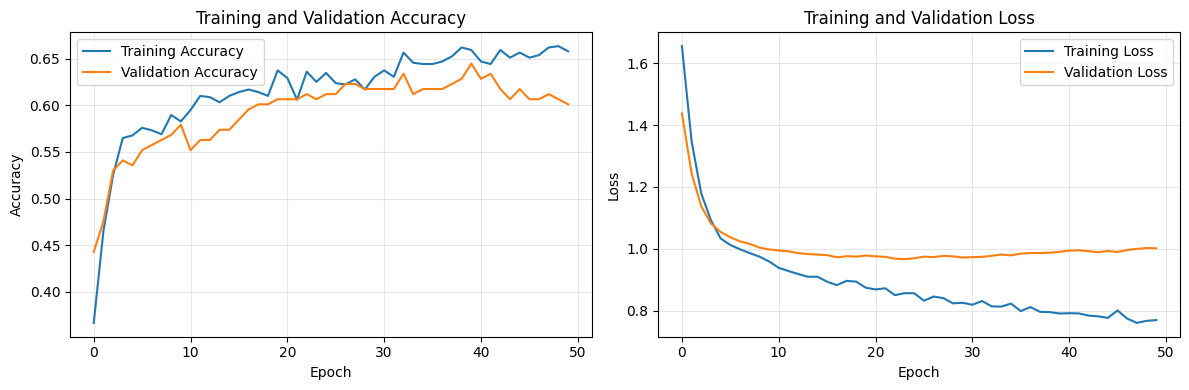

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"], label="Training Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion

The Wine Quality dataset was prepared using a stratified train-test split and feature standardization. A Multilayer Perceptron was then trained for multiclass wine-quality classification. Model performance was evaluated using test accuracy and a confusion matrix.